Analysis into if cmems is more accurate based off of the initial abbility to predict the the dFADs speeds

- Start by using compairson of CMEMs and the dFADs speeds at current time 
    Produce plot of inital cmems speed errors vs leadtime errors. 
    create a list of all the innital speed errors 


In [267]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
from importlib import reload
import functions.funcs as funcs 
reload(funcs)
import matplotlib.pyplot as plt

In [268]:
ds = gpd.read_parquet(r"Data\MappedOSCAR_SAT_MI_Cleanedspeeds.parquet") 
ds = funcs.querry_date_range(ds, pd.Timestamp("2024-1-1"), pd.Timestamp("2025-1-1"))
ds = ds.reset_index(drop = True)
fc = pd.read_csv("Parcels/saved_output/combined_cmems2024.csv")
fc1 = pd.read_csv("Parcels/saved_output/OSCAR_2024v2.csv")

fc2 = pd.read_csv("Parcels/saved_output/optimal_cmems_OSCAR_2024.csv")
fc3 = pd.read_csv("Parcels/saved_output/No_forecast.csv")
fc["Time"] = pd.to_datetime(fc["Time"])
fc['error_km'] = funcs.haversine_df(fc, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc1["Time"] = pd.to_datetime(fc1["Time"])
fc1['error_km'] = funcs.haversine_df(fc1, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc2["Time"] = pd.to_datetime(fc2["Time"])
fc2["error_km"] = funcs.haversine_df(fc2, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc3["Time"] = pd.to_datetime(fc3["Time"])
fc3["error_km"] = funcs.haversine_df(fc3, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
ds.columns

Index(['index', 'BuoyName', 'MinOfDate', 'MaxOfDate', 'TimeStamp', 'geometry',
       'x_deg', 'y_deg', 'x_km', 'y_km', 'xy_km', 'Delta_Timestamps',
       'x_speed', 'y_speed', 'xy_speed', 'points_removed', 'Masked_array',
       'points_removed2', 'Masked_array2', 'Masked_array_combined', 'mapped_v',
       'mapped_u', 'mapped_v_oscar', 'mapped_u_oscar'],
      dtype='str')

In [269]:

print(fc1.columns)

Index(['Unnamed: 0', 'BuoyID', 'Time', 'lat_true', 'lon_true', 'lat_forcast',
       'lon_forcast', 'leadtime', 'error_km'],
      dtype='str')


In [270]:
fc2.query("leadtime == 0").shape

(8429, 11)

In [271]:
def add_starttime(fc):
    fc["starttime"] = (fc["Time"] - pd.to_timedelta(fc["leadtime"], unit= "hours")).dt.round("min")
    return fc

In [272]:
longlist = pd.DataFrame({})
longlist["Time"] = funcs.Column_to_List(ds, "TimeStamp", idlist = False)
longlist["lats"], longlist["lons"] = funcs.list_of_latlon(ds, False)
longlist["x_speed"] = funcs.Column_to_List(ds, "x_speed", idlist = False)
longlist["y_speed"] = funcs.Column_to_List(ds, "y_speed", idlist = False)
longlist["v_mapped"], longlist["BuoyID"]  =funcs.Column_to_List(ds, "mapped_v", idlist = True)
longlist["v_mapped_OSCAR"], longlist["BuoyID"]  =funcs.Column_to_List(ds, "mapped_v_oscar", idlist = True)
longlist["u_mapped"] = funcs.Column_to_List(ds, "mapped_u", idlist = False)
longlist["u_mapped_OSCAR"] = funcs.Column_to_List(ds, "mapped_u_oscar", idlist = False)
longlist.Time = pd.to_datetime(longlist.Time)
mask = (longlist.Time > pd.Timestamp('2023-12-31')) 
longlist = longlist[mask].reset_index(drop = True)
longlist = longlist[longlist.Time < pd.Timestamp('2025-1-1')].reset_index(drop = True)

In [273]:
## maps the True dFAD dFADs speeds onto 
def merge_forecast_true(fc, longlist):
    merged = pd.merge_asof(
    fc.sort_values('Time'),
    longlist.sort_values('Time'),
    on='Time',
    by='BuoyID',
    tolerance=pd.Timedelta(minutes=1),
    direction='nearest'
    )
    return merged

merged = merge_forecast_true(fc, longlist)
merged["speed"] = np.sqrt(merged.x_speed**2 + merged.y_speed**2)
merged["starttime"] = (merged.Time - pd.to_timedelta(merged.leadtime, "hours")).dt.round('min')
merged = merged.sort_values('Time')
merged["initial_speed"] = merged.groupby(by=["BuoyID", "starttime"])['speed'].transform('first')
## plot for just 24 hours 
bins = np.linspace(0,8*24,2*24+1)
merged["lead_bins"] = pd.cut(merged["leadtime"], bins)
binlist = merged["lead_bins"].unique()
a  =binlist[7] ## list of bin intervals 
print(a)
mergedhr = merged.groupby("lead_bins").get_group(a)
##now group by speeds and take a mean.
speedbins = np.linspace(0,mergedhr.initial_speed.max(),25 )
mergedhr["speed_bin"] = pd.cut(mergedhr["initial_speed"], speedbins)
binned_errors = mergedhr.groupby("speed_bin")["error_km"].mean()

(24.0, 28.0]


### Speed Corrilations with errors.

In [274]:
def inital_speed_binning(merged: pd.DataFrame, binindex : int):
    bins = np.linspace(0,8*24,2*24+1)
    merged["lead_bins"] = pd.cut(merged["leadtime"], bins)
    binlist = merged["lead_bins"].unique()
    a  =binlist[binindex] ## list of bin intervals 
    print(a)
    mergedhr = merged.groupby("lead_bins").get_group(a)
    ##now group by speeds and take a mean.
    speedbins = np.linspace(0,mergedhr.initial_speed.max(),25)
    mergedhr["speed_bin"] = pd.cut(mergedhr["initial_speed"], speedbins)
    binned_errors = mergedhr.groupby("speed_bin")["error_km"].mean()
    return speedbins, binned_errors

speedbins, binned_errors = inital_speed_binning(merged,8)

(28.0, 32.0]


(0.0, 4.0]
(4.0, 8.0]
(8.0, 12.0]
(12.0, 16.0]
(16.0, 20.0]
(20.0, 24.0]
(24.0, 28.0]
(28.0, 32.0]
(32.0, 36.0]
(36.0, 40.0]


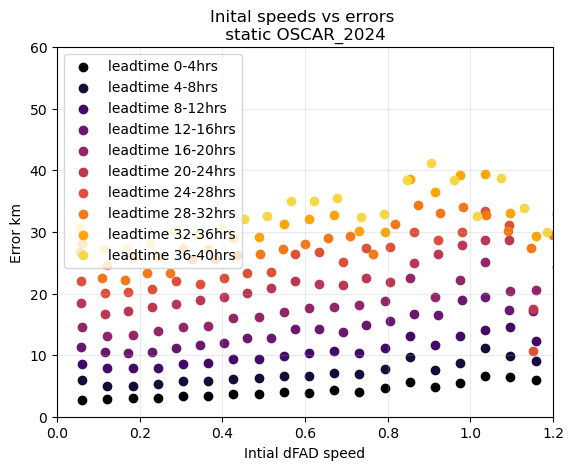

In [275]:
fig, ax = plt.subplots()
cmap = plt.cm.inferno
for i in range(10):
    speedbins, binned_errors = inital_speed_binning(merged,i+1)
    ax.scatter(speedbins[1:], binned_errors, label=f"leadtime {i*4}-{(i+1)*4}hrs", color=cmap(i/10))
ax.set_ylabel("Error km")
ax.set_xlabel("Intial dFAD speed")
ax.set_xlim(0,1.2)
ax.set_ylim(0,60)
ax.set_title("Inital speeds vs errors \n static OSCAR_2024 ")
ax.grid(alpha = 0.25)
ax.legend()

### analyzing optimal forecasting dataset

In [276]:
### plot simple time series of Percent cmems or OSCAR

fc2i= fc2.query("leadtime == 0").reset_index(drop = True).sort_values("Time")
fc2i["Day"] = fc2i.Time.dt.date
print(f"Fraction of cmems forecasts : {fc2i.query("model == 'cmems'")["model"].count()/fc2i.model.count() :0.4}")

percentcmems = fc2i.groupby("Day").apply(lambda x: (x["model"] == "cmems").sum() / len(x) * 100)
percentcmems = percentcmems.to_frame().rename(columns = {0: "cmems"})
percentcmems["rolling"] = percentcmems.cmems.rolling(7).mean()

Fraction of cmems forecasts : 0.3105


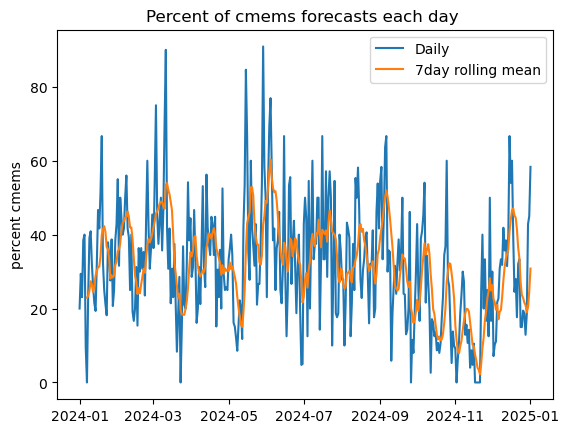

In [277]:
fig, ax = plt.subplots()
ax.plot(percentcmems.index, percentcmems.values, label = ["Daily", "7day rolling mean"])
ax.set_ylabel("percent cmems")
ax.set_title("Percent of cmems forecasts each day ")
ax.legend()

In [278]:
### merging forecast data with mapped speeds
oscar = fc2.query("model == 'OSCAR'").reset_index(drop = True)
oscar_merged = merge_forecast_true(oscar, longlist)
oscar_merged = oscar_merged.rename(columns= {"u_mapped_OSCAR" : "u_mapped_comb", "v_mapped_OSCAR": "v_mapped_comb"})

cmems = fc2.query("model =='cmems'").reset_index(drop = True)
cmems_merged = merge_forecast_true(cmems, longlist)
cmems_merged = cmems_merged.rename(columns= {"u_mapped" : "u_mapped_comb", "v_mapped": "v_mapped_comb"})
fc_opt = pd.concat([cmems_merged, oscar_merged])

In [279]:
fc_opt["projection"] = (fc_opt.y_speed * fc_opt.v_mapped_comb)+ (fc_opt.x_speed * fc_opt.u_mapped_comb)
fc_opt["projection"]  = fc_opt["projection"]/(fc_opt.x_speed**2 +fc_opt.y_speed**2 )**(1/2)
fc_opt["initial_angle"] = fc_opt["projection"]/(fc_opt.u_mapped_comb**2 +fc_opt.v_mapped_comb**2 )**(1/2)
fc_opt["initial_angle"] = np.arccos(fc_opt["initial_angle"])*180/np.pi
fc_opt_saved = fc_opt.copy()

### Projection of dFAD onto the model speeds vs errors. 


In [280]:
def calc_projection_initial_angle(merged, sufix = None):
    projection = "projection"
    initial_angle = "initial_angle"
    u = "u_mapped"
    v = "v_mapped"
    if sufix is not None:
        projection +=sufix
        initial_angle +=sufix
        u += sufix
        v+= sufix 
    merged[projection] = (merged.y_speed * merged[v])+ (merged.x_speed * merged[u])
    merged[projection]  = merged[projection]/(merged.x_speed**2 +merged.y_speed**2 )**(1/2)
    merged[initial_angle] = merged[projection]/(merged[u]**2 +merged[v]**2 )**(1/2)
    merged[initial_angle] = np.arccos(merged[initial_angle])*180/np.pi
    return merged

merged = calc_projection_initial_angle(merged)

### Adding for OSCAR
merged["projection_OSCAR"] = (merged.y_speed * merged.v_mapped_OSCAR)+ (merged.x_speed * merged.u_mapped_OSCAR)
merged["projection_OSCAR"]  = merged["projection_OSCAR"]/(merged.x_speed**2 +merged.y_speed**2 )**(1/2)
merged["initial_angle_OSCAR"] = merged["projection_OSCAR"]/(merged.u_mapped_OSCAR**2 +merged.v_mapped_OSCAR**2 )**(1/2)
merged["initial_angle_OSCAR"] = np.arccos(merged["initial_angle_OSCAR"])*180/np.pi


def Projection_binning(merged: pd.DataFrame, label:str, binindex : int):
    bins = np.linspace(0,8*24,2*24+1)
    merged["lead_bins"] = pd.cut(merged["leadtime"], bins)
    binlist = merged["lead_bins"].unique()
    a  =binlist[binindex] ## list of bin intervals 
    print(a)
    mergedhr = merged.groupby("lead_bins").get_group(a)
    ##now group by speeds and take a mean.
    speedbins = np.linspace(mergedhr[label].min(),mergedhr[label].max(),25)
    mergedhr["projection_bin"] = pd.cut(mergedhr[label], speedbins)
    binned_errors = mergedhr.groupby("projection_bin")["error_km"].mean()
    return speedbins, binned_errors

speedbins, binned_errors = Projection_binning(merged,"projection", 1)

speedbins[binned_errors.index.codes]


(0.0, 4.0]


array([-0.78453474, -0.62508182, -0.54535537, -0.46562891, -0.38590245,
       -0.30617599, -0.22644953, -0.14672307, -0.06699662,  0.01272984,
        0.0924563 ,  0.17218276,  0.25190922,  0.33163568,  0.41136213,
        0.49108859,  0.57081505,  0.65054151,  0.73026797,  0.80999442,
        0.88972088,  0.96944734])

(24.0, 28.0]
(28.0, 32.0]
(32.0, 36.0]
(36.0, 40.0]
(40.0, 44.0]
(44.0, 48.0]
(48.0, 52.0]
(52.0, 56.0]
(56.0, 60.0]
(60.0, 64.0]


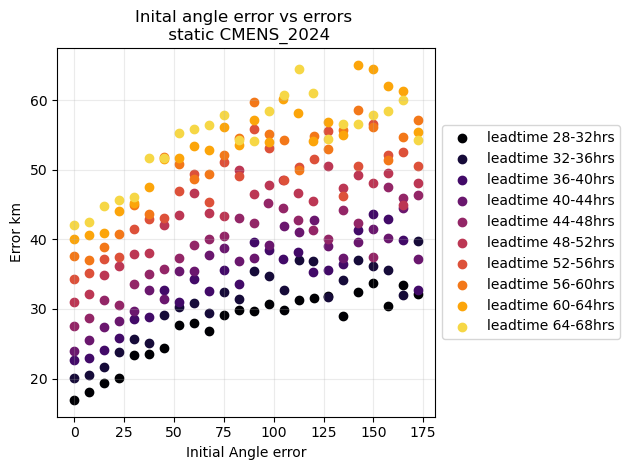

In [281]:
fig, ax = plt.subplots()
cmap = plt.cm.inferno
ofset = 7
timerange = 10
for i in range(timerange):
    speedbins, binned_errors = Projection_binning(merged,"initial_angle", i+ofset)
    ax.scatter(speedbins[binned_errors.index.codes], binned_errors, label=f"leadtime {(i+ofset)*4}-{(i+ofset+1)*4}hrs", color=cmap(i/timerange))
ax.set_ylabel("Error km")
ax.set_xlabel("Initial Angle error")
#ax.set_xlim(0,1.2)
#ax.set_ylim(0,60)
ax.set_title("Inital angle error vs errors \n static CMENS_2024")
ax.grid(alpha = 0.25)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()

In [282]:
## remove duplicate forecasts
def add_inital_time(ds:pd.DataFrame):
    """adds intial time of forecast (time - leadtime) and changes collumns to pd.DateTime objects"""
    ds["Time"] = pd.to_datetime(ds["Time"])
    ds["initial_time"] =  ds["Time"] - pd.to_timedelta(ds["leadtime"], unit = "hours")
    ds["initial_time"] = ds["initial_time"].dt.round(freq = "min")
    return ds
merged = add_inital_time(merged)
merged_clean = merged.drop_duplicates(subset=['BuoyID', 'initial_time', 'leadtime'], keep='first')

8429

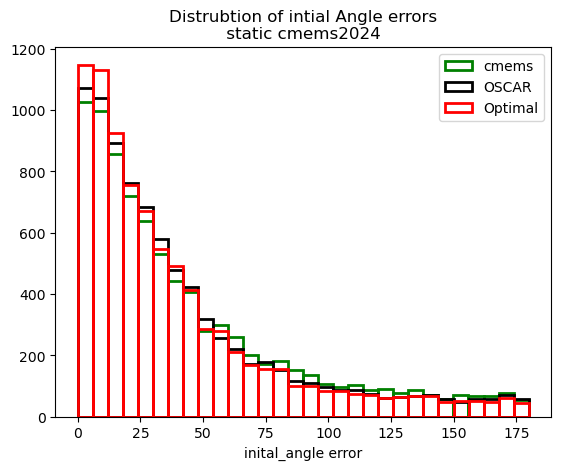

In [283]:
### distribution of inittial error speeds. 
initial_speeds = merged_clean.query("leadtime == 0")
initial_speeds_opt = fc_opt.query("leadtime == 0")
Greater90 = initial_speeds.query("initial_angle > 90")["initial_angle"].count()
fig, ax =plt.subplots()
ax.hist(initial_speeds.initial_angle, 30, fill= None, edgecolor = "g", lw =2, label = "cmems")
ax.hist(initial_speeds.initial_angle_OSCAR, 30, fill= None, edgecolor = "k", lw = 2, label = "OSCAR")
ax.hist(initial_speeds_opt.initial_angle, 30, fill= None, edgecolor = "r", lw = 2, label = "Optimal")
ax.set_xlabel("inital_angle error")
ax.set_title("Distrubtion of intial Angle errors\n static cmems2024 ")
ax.legend()
Greater90/initial_speeds.initial_angle.count()
initial_speeds.shape[0]
initial_speeds_opt.shape[0]

In [284]:
## checking number of forecasts 
print(initial_speeds.shape, initial_speeds_opt.shape)

(8429, 26) (8429, 23)


### Time Series of Errors 

In [285]:

bins = np.linspace(0,8*24,2*24+1)
fc["lead_bins"] = pd.cut(merged["leadtime"], bins)
binlist = fc["lead_bins"].unique()

def Forecast_timeseries(ds:pd.DataFrame, window:int, bin)-> pd.DataFrame:
    bins = np.linspace(0,8*24,2*24+1)
    ds["lead_bins"] = pd.cut(ds["leadtime"], bins)
    # (24.0, 28.0]
    fc_grouped = ds.groupby("lead_bins")
    fc24 = fc_grouped.get_group(a)
    fc24["Day"] = fc24.Time.dt.date
    ts24 = fc24.groupby("Day")["error_km"].mean()
    ts24 = ts24.to_frame("error_km").reset_index(drop= False)
    ts24["rolling"] = ts24["error_km"].rolling(window).mean()
    return ts24

In [286]:
window = 7
a = binlist[18]
print(a)
fcts = Forecast_timeseries(fc, window , a)
fcts2 = Forecast_timeseries(fc2,window, a)
fcts3 = Forecast_timeseries(fc3, window, a)

(68.0, 72.0]


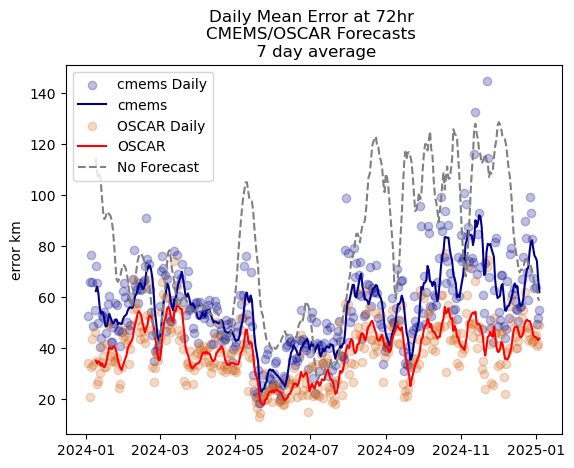

In [287]:
fig, ax = plt.subplots()
#CMEMS
ax.scatter(fcts.Day, fcts.error_km, color = "darkblue", alpha = 0.25, label = "cmems Daily")
ax.plot(fcts.Day, fcts["rolling"], color = "darkblue", label = "cmems")
#OSCAR 
ax.scatter(fcts2.Day, fcts2.error_km, color = "chocolate", alpha = 0.25 ,label = "OSCAR Daily")
ax.plot(fcts2.Day, fcts2["rolling"], color = "red", label = "OSCAR")
#NO Forecast
#ax.scatter(fcts3.Day, fcts3.error_km, color = "g", alpha = 0.25 ,label = "OSCAR Daily")
ax.plot(fcts3.Day, fcts3["rolling"], color = "gray", label = "No Forecast", linestyle = "--")
ax.set_title("Daily Mean Error at 72hr \nCMEMS/OSCAR Forecasts \n 7 day average")
ax.set_ylabel("error km")
ax.legend()

Text(0.5, 1.0, 'mean daily speed \n cmems2024')

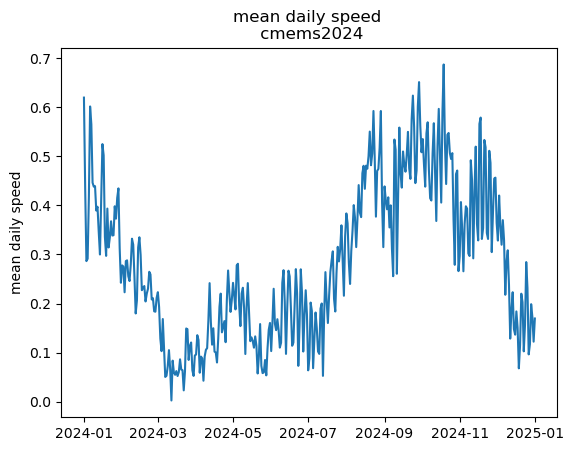

In [288]:
import xarray as xr 
cmems =xr.open_dataset(r"Data\cmems.nc")
cmems = cmems.sel(time = slice("2024-01-01", "2025-01-01"), depth = 15.81007  )
fig, ax = plt.subplots()
speed = np.sqrt(cmems.uo.mean(dim = ["latitude", "longitude"])**2 + cmems.vo.mean(dim = ["latitude", "longitude"])**2)
ax.plot(cmems.time, speed)
ax.set_ylabel("mean daily speed")
ax.set_title("mean daily speed \n cmems2024")

### Creating forecast based off of initial error

In [289]:
oscar_merged = merge_forecast_true(fc1, longlist)
cmems_merged = merge_forecast_true(fc, longlist)
##remove duplicate forecasts start at the same time 


## calcuate inital angle for both
oscar_merged = calc_projection_initial_angle(oscar_merged, "_OSCAR")
cmems_merged = calc_projection_initial_angle(cmems_merged)
oscar_merged = calc_projection_initial_angle(oscar_merged)
cmems_merged = calc_projection_initial_angle(cmems_merged, "_OSCAR")
cmems_merged["starttime"] = cmems_merged['Time']- pd.to_timedelta(cmems_merged["leadtime"],unit = "hours").dt.round("min")
oscar_merged["starttime"] = oscar_merged['Time']- pd.to_timedelta(oscar_merged["leadtime"], unit="hours").dt.round("min")

In [303]:
## For each forecast decide which one is better based off of initial angle. 
def lower_initial_angle(group):
    if group.empty:
        return group

    idx = group["leadtime"].idxmin()
    cmemsi = group.at[idx, "initial_angle"] 
    oscari = group.at[idx, "initial_angle_OSCAR"] 

    choice = "cmems" if cmemsi < oscari else "OSCAR"

    g = group.copy()
    g["best_model"] = choice
    return g
    

cmems_grouped = cmems_merged.groupby(["BuoyID", "starttime"]).apply(lower_initial_angle)
OSCAR_grouped = oscar_merged.groupby(["BuoyID", "starttime"]).apply(lower_initial_angle)
#cmems_grouped.reset_index().query("leadtime == 0").query("best_model == 'OSCAR'").shape[0]

cmems_forecasts = cmems_grouped.reset_index().query("best_model == 'cmems'")
oscar_forecasts = OSCAR_grouped.reset_index().query("best_model == 'OSCAR'")
oscar_forecasts["initial_angle_used"] = oscar_forecasts["initial_angle_OSCAR"]
cmems_forecasts["initial_angle_used"] = cmems_forecasts["initial_angle"]

ia_forecast = pd.concat([oscar_forecasts,cmems_forecasts])

In [304]:
print(oscar_forecasts[["lat_forcast", "lon_forcast"]])
cmems_forecasts[["lat_forcast", "lon_forcast"]]

        lat_forcast  lon_forcast
23              NaN          NaN
24         5.183369  -162.985016
25         5.156633  -162.949788
26         5.129242  -162.915912
27         5.101399  -162.883749
...             ...          ...
261095     4.936201  -161.014528
261106          NaN          NaN
261107     5.310804  -160.869369
261108     5.338368  -160.821033
261109     5.364015  -160.770843

[136158 rows x 2 columns]


,lat_forcast,lon_forcast
0,NaN,NaN
1,5.400520,-163.486079
2,5.404637,-163.434782
3,5.404304,-163.385507
4,5.400431,-163.337002
...,...,...
261101,4.997279,-161.004260
261102,5.012764,-160.963245
261103,5.027016,-160.922571
261104,5.041032,-160.881480


In [305]:
### now want to compair to the optimal forecasting method and see how many we have gotten right( picked cmems or oscar correctly) 

fc_opt = merge_forecast_true(fc2, longlist)
fc_opt = add_starttime(fc_opt)
# get unique groups as a dataframe
grouped_opt = fc_opt[["BuoyID", "starttime", "model"]].drop_duplicates().reset_index(drop=True)
grouped_ia = ia_forecast[["BuoyID", "starttime", "best_model"]].drop_duplicates().reset_index(drop =True) 
print(len(grouped_ia), len(grouped_opt))
# Find groups that appear in both dataframes
merged_groups = pd.merge(grouped_ia, grouped_opt, on=['BuoyID', 'starttime'], how='inner')
common_groups = merged_groups[['BuoyID', 'starttime']].drop_duplicates()
print(f"Number of groups in both: {len(common_groups)}")


8429 8429
Number of groups in both: 8429


In [306]:
#compair two comulms of the data set and produce a new column with 1 being the values in that row  are the same and 
merged_groups["correct"] = (merged_groups["best_model"] == merged_groups["model"]).astype(int)
corect_forecasts = merged_groups[ merged_groups.correct == 1]
incorrect_forecasts = merged_groups[merged_groups.correct != 1]
print(f"Percent of correct model chosen {corect_forecasts.shape[0]/merged_groups.shape[0]}")

Percent of correct model chosen 0.57847906038676


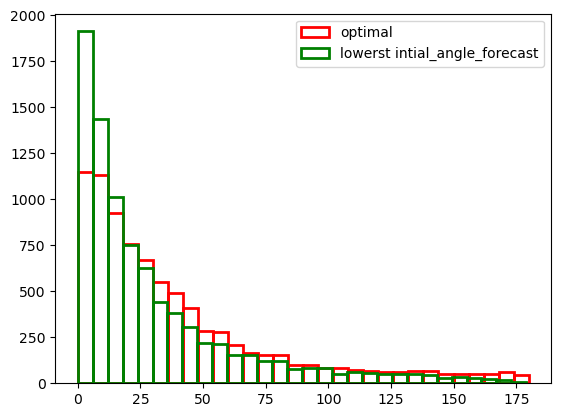

In [307]:
## hsitorgram like above of distribution of intial angle errors. 
fc_optia = fc_opt_saved.copy()
fc_optia = fc_optia.query("leadtime == 0")
intial_times_ia = ia_forecast.query("leadtime == 0")
fig, ax = plt.subplots()
ax.hist(fc_optia.initial_angle, 30, fill= None, edgecolor = "r", lw =2, label = "optimal")
ax.hist(intial_times_ia.initial_angle_used, 30, fill= None, edgecolor = "g", lw =2, label = "lowerst intial_angle_forecast")
ax.legend()

In [308]:
### saving initial angle forecasts 
ia_save = ia_forecast[["BuoyID", "Time", "lat_true", "lon_true", "lon_forcast", "lat_forcast", "leadtime", "best_model", "initial_angle_used"]]
ia_save.to_csv(r"Parcels\saved_output\initial_angle_forecasts.csv")

In [312]:
ia_forecast_less90 = ia_forecast[ia_forecast["initial_angle_used"] < 90]
ia_forecast_less90.to_csv("Parcels\saved_output\initial_angle_forecasts_less90.csv")

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_21404\2265086388.py:2: SyntaxWarning: invalid escape sequence '\s'
  ia_forecast_less90.to_csv("Parcels\saved_output\initial_angle_forecasts_less90.csv")
